```{index} single: Pyomo; block
```
```{index} single: application; production planning
```
```{index} single: solver; HiGHS
```
```{index} single: Pyomo; persistent solvers
```
```{index} robust optimization
```
```{index} two-stage problem
```
```{index} constraint and column generation
```

# 10.2 Two-stage production planning using constraint and column generation

The purpose of this notebook is to demonstrate a range of techniques for two-stage optimization (robust and stochastic) using a range of techniques:
* Robust Optimization (including Constraint and Column Generation)
* Stochastic Optimization (including the SAA method)

## Preamble: install Pyomo, HiGHS and SCIP

The linear models in this notebook use Pyomo and HiGHS. The final constraint and column generation section also uses SCIP through PySCIPOpt to solve a nonconvex worst-case subproblem globally. This extra solver is needed because uncertainty affects the recourse coefficients as well as the right-hand side.

On Google Colab the following cell installs the packages. For a local environment, install them first with `python -m pip install pyomo highspy pyscipopt`. Supported PySCIPOpt binary packages include SCIP; see the [installation guide](https://pyscipopt.readthedocs.io/en/stable/install.html). A local nonlinear solver alone would not provide the global lower bounds used in the stopping test.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install pyomo >/dev/null 2>/dev/null
    %pip install highspy >/dev/null 2>/dev/null
    %pip install pyscipopt

solver = "appsi_highs"

import pyomo.environ as pyo

SOLVER = pyo.SolverFactory(solver)

assert SOLVER.available(), f"Solver {solver} is not available."


def solve_checked(model):
    results = SOLVER.solve(model)
    pyo.assert_optimal_termination(results)
    return results

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Problem Statement

Consider again the production planning example from [Chapter 1](../01/01.00.md) where a small startup company has announced the initial production of two models, $U$ and $V$. For completeness we first recall the problem setting and then introduce the additional layer of uncertainty:

* Model $U$ is the higher-priced version requiring 10 units of raw material. The labor requirement is estimated to be 1 hour of labor A and 2 hours of labor B. The $U$ model will sell for 270€ per unit.

* Model $V$ requires 9 units of the same raw materials and is estimated to require 1 hour of labor A and 1 hour of labor B. Model $V$ sells for 210€ per unit with unlimited demand.

* A pre-production  marketing campaign offers guaranteed delivery of model $U$ in return for a down payment. Initially it is expected that the number of such orders will be 20 units. Because of the higher price, the demand for model $U$ is limited so no more than 40 units will be produced.

* The raw materials cost 10€ per unit. The raw materials have a long lead time and must be ordered now. Unused raw materials have no waste value. 

* Given current staffing, there are 80 hours of labor A available at a cost of 50€/hour, and 100 hours of labor B available at a cost of 40€/hour.

* The company will not have accurate knowledge of the labor required to produce each product until production starts. The estimated amount of labor A and labor B needed for each unit produced could be off by 15% and 25%, respectively. Additionally, there is uncertainty about the amount of down-payment demand for model $U$ -- it can differ by up to 25%, up or down, from the nominal value of 20. We model simultaneous deviations with a budget of two: the sum of the three absolute deviations, each divided by its maximum, is at most two.

The company's chief operating officer (COO) must decide how much raw material to order now without complete information about the labor needed to manufacture the models or knowledge about the outcome of the pre-production marketing campaign. If the COO orders too much now then raw material will be left over and wasted. If the COO orders too little then a profit opportunity will be lost. In either case, the profit realized will be less than the potential. In what way can the best decision be made?

## Problem description

The problem has a clear two-stage structure: the ordering of the raw material has to be done before the unknown demand is observed and the labor requirements are known. The decisions about the amount of two models to be produced can be, however, made with full information about the uncertainty.

As for the uncertainty itself, no information is given other than the set of values the respective parameters can take:
* $z_A$: Relative uncertainty in the amount of labor A required to produce each unit of product,
* $z_B$: Relative uncertainty in the amount of labor B required to produce each unit of product,
* $z_D$: Relative uncertainty in the number of initial orders for product $U$,

where

$$
\begin{align*}
|z_A| & \leq 0.15 && \pm \text{15\% uncertainty in Labor }A \\
|z_B| & \leq 0.25 && \pm \text{25\% uncertainty in Labor }B \\
|z_D| & \leq 0.25 &&  \text{25\% uncertainty in initial orders for }U \\
\end{align*}
$$

The simultaneous deviations satisfy the following budget constraint:

$$
\begin{align*}
\frac{|z_A|}{0.15} + \frac{|z_B|}{0.25} + \frac{|z_D|}{0.25} \leq 2.
\end{align*}
$$

Let us see how these parameters $z_A$ and $z_B$ affect the problem.  After subtracting labor and the raw material used per device, the unit margins are:

$$
\begin{align*}
P_U & = 270 - 50(1+z_A) - 80(1+z_B) - 100 \\
& = 40 - 50 z_A - 80 z_B \\
\implies P_U & \in [12.5, 67.5] \\
\\
P_V & = 210 - 50(1+z_A) - 40(1+z_B) - 90 \\
& = 30 - 50 z_A - 40 z_B \\
\implies P_V  & \in [12.5, 47.5]
\end{align*}
$$

It is therefore not clear in advance which of the products would be more profitable. Taking into account the additional uncertainty about the preorder demand for product $U$, it is not possible to determine in advance what is the worst-case outcome of the uncertainty $z_A$, $z_B$, $z_D$ for this problem.

Since we have no information about the underlying probability distribution of the uncertain parameters, a natural approach is to solve this problem with a worst-case formulation in mind. However, for sake of completeness, we also investigate how the optimal solution would look if each realization of $(z_A, z_B, z_D)$ was equally probable.

## Two-stage problem formulation

Let $x$ be the amount of raw material ordered before the uncertainty is observed. The robust problem is

$$
\max_{x\geq 0}\; -10x + \min_{z\in Z} Q(x,z),
$$

where the same budgeted set is used throughout the notebook:

$$
Z=\left\{z:\ |z_A|\leq0.15,\ |z_B|\leq0.25,\ |z_D|\leq0.25,
\quad \frac{|z_A|}{0.15}+\frac{|z_B|}{0.25}+\frac{|z_D|}{0.25}\leq2\right\}.
$$

The recourse variables $y_1$ and $y_2$ are the quantities of $U$ and $V$ produced after observing $z$. Production is continuous in this example. The auxiliary variable $y_3$ measures sales revenue minus labor costs; raw material is charged separately through $-10x$, including unused material. Thus

$$
\begin{aligned}
Q(x,z)=\max\quad & y_3\\
\text{s.t.}\quad & (140-50z_A-80z_B)y_1+(120-50z_A-40z_B)y_2\geq y_3\\
&y_1\geq20(1+z_D) &&\text{(preorders)}\\
&(1+z_A)(y_1+y_2)\leq80 &&\text{(labor A)}\\
&(1+z_B)(2y_1+y_2)\leq100 &&\text{(labor B)}\\
&10y_1+9y_2\leq x &&\text{(raw materials)}\\
&y_1\leq40 &&\text{(maximum demand for U)}\\
&y_1,y_2,y_3\geq0.
\end{aligned}
$$

In the notation $R(z)x+S(z)y\leq t(z)$, with $y=(y_1,y_2,y_3)^\top$, the data are

$$
c=(-10),\qquad q=(0,0,1)^\top,
$$

$$
R(z)=\begin{pmatrix}0\\0\\0\\0\\-1\\0\end{pmatrix},\quad
S(z)=\begin{pmatrix}
-(140-50z_A-80z_B)&-(120-50z_A-40z_B)&1\\
-1&0&0\\
1+z_A&1+z_A&0\\
2(1+z_B)&1+z_B&0\\
10&9&0\\
1&0&0
\end{pmatrix},\quad
t(z)=\begin{pmatrix}0\\-20(1+z_D)\\80\\100\\0\\40\end{pmatrix}.
$$

For feasibility under every $z\in Z$, we need $x\geq250$: the possible 25 preorders require 250 units of material. This is also sufficient for recourse feasibility, since producing only those preorders respects both labor capacities and the upper demand limit. We will use this bound in the continuous-set robust algorithm. The earlier nominal and sampled models only enforce their stated scenarios.

## Solving the robust problem using sampled scenarios

How can we actually solve such a two-stage problem if it is indeed the worst-case profit that we are interested in? Note that the matrix $S(z)$ depends on $z$ and, therefore, we cannot easily formulate the second-stage decisions as linear functions of $z$ (linear decision rules). However, we can generate a finite list of $N$ scenarios and solve a problem that will maximize the worst-case profit across such a set of scenarios:

$$
\begin{align*}
\max \quad & c^\top x + \tau  \\ 
\text{s.t.} \quad  & q^\top y^j \geq \tau, && j = 1, \ldots, N  \\
& R (z^j) x + S(z^j) y^j \leq t(z^j)  &&  j = 1, \ldots, N \\
& x, y^1, \ldots, y^N \geq 0,\quad \tau\in\mathbb{R} 
\end{align*}
$$

We first define an auxiliary function that evaluates the system matrix coefficients for a particular scenario $z \in Z$ and returns them as nested dictionaries.

A finite sample gives an upper bound on the optimal continuous-set worst-case profit, not a guarantee against all possible realizations. We use the same fixed sample for the subsequent average-case comparisons.

In [4]:
# Function to return the vectors and matrices c, q, R, S, t evaluated for a specific realization (z_A, z_B, z_D)
def model_params(z_A=0, z_B=0, z_D=0):
    c = {"x": -10}

    q = {"y1": 0, "y2": 0, "y3": 1}

    R = {
        "profit": {"x": 0},
        "demand": {"x": 0},
        "labor A": {"x": 0},
        "labor B": {"x": 0},
        "raw materials": {"x": -1},
    }

    S = {
        "profit": {
            "y1": -(140 - 50 * z_A - 80 * z_B),
            "y2": -(120 - 50 * z_A - 40 * z_B),
            "y3": 1,
        },
        "demand": {"y1": -1, "y2": 0, "y3": 0},
        "labor A": {"y1": 1 + z_A, "y2": 1 + z_A, "y3": 0},
        "labor B": {"y1": 2 + 2 * z_B, "y2": 1 + z_B, "y3": 0},
        "raw materials": {"y1": 10, "y2": 9, "y3": 0},
    }

    t = {
        "profit": 0,
        "demand": -20 * (1 + z_D),
        "labor A": 80,
        "labor B": 100,
        "raw materials": 0,
    }

    R["maximum demand"] = {"x": 0}
    S["maximum demand"] = {"y1": 1, "y2": 0, "y3": 0}
    t["maximum demand"] = 40
    return c, q, R, S, t


c, q, R, S, t = model_params()

print(f"c = {c}")
print(f"q = {q}")
print(f"R = {R}")
print(f"S = {S}")
print(f"t = {t}")

c = {'x': -10}
q = {'y1': 0, 'y2': 0, 'y3': 1}
R = {'profit': {'x': 0}, 'demand': {'x': 0}, 'labor A': {'x': 0}, 'labor B': {'x': 0}, 'raw materials': {'x': -1}, 'maximum demand': {'x': 0}}
S = {'profit': {'y1': -140, 'y2': -120, 'y3': 1}, 'demand': {'y1': -1, 'y2': 0, 'y3': 0}, 'labor A': {'y1': 1, 'y2': 1, 'y3': 0}, 'labor B': {'y1': 2, 'y2': 1, 'y3': 0}, 'raw materials': {'y1': 10, 'y2': 9, 'y3': 0}, 'maximum demand': {'y1': 1, 'y2': 0, 'y3': 0}}
t = {'profit': 0, 'demand': -20, 'labor A': 80, 'labor B': 100, 'raw materials': 0, 'maximum demand': 40}


We define Pyomo model to maximize the worst-case profit for a set of scenarios, where the block structure is used to repeat the parts of the model which are structurally identical for each outcome of $z$.

We generate $N=1000$ scenarios sampling uniformly at random from the given uncertainty set. We then solve both the nominal problem (inputting a single scenario with the nominal values for the parameters) and the robust problem using $N=1000$ samples. 

In [5]:
# Sample the random variables z_A, z_B, z_D uniformly in the given set
def z_sample(seed):
    rng = np.random.default_rng(seed)
    while True:
        sample = {
            "z_A": 0.15 * rng.uniform(low=-1, high=1),
            "z_B": 0.25 * rng.uniform(low=-1, high=1),
            "z_D": 0.25 * rng.uniform(low=-1, high=1),
        }
        if (
            abs(sample["z_A"]) / 0.15
            + abs(sample["z_B"]) / 0.25
            + abs(sample["z_D"]) / 0.25
            <= 2
        ):
            break
    return sample


# Get a sample of 1000 realizations of the random variables z_A, z_B, z_D
N = 1000
Z = [z_sample(j) for j in range(N)]


# Function to solve the robust problem using the sampled realizations
def max_min_profit(model_params, Z):
    m = pyo.ConcreteModel("Worst case problem")

    # first stage variables
    c, q, *_ = model_params()

    m.I = pyo.Set(initialize=c.keys())
    m.J = pyo.Set(initialize=q.keys())

    m.x = pyo.Var(m.I, domain=pyo.NonNegativeReals)
    m.tau = pyo.Var()

    m.SCENARIOS = pyo.Set(initialize=range(len(Z)))

    @m.Block(m.SCENARIOS)
    def scenario(b, s):
        # get model parameters for the scenario
        _, q, R, S, t = model_params(**Z[s])

        # second stage variables
        b.y = pyo.Var(b.model().J, domain=pyo.NonNegativeReals)

        @b.Constraint()
        def stage_net_profit(b):
            return b.y["y3"] >= b.model().tau

        @b.Constraint(S.keys())
        def model_constraints(b, k):
            return (
                sum(R[k][i] * b.model().x[i] for i in b.model().I)
                + sum(S[k][j] * b.y[j] for j in b.model().J)
                <= t[k]
            )

    # worst case profit
    @m.Objective(sense=pyo.maximize)
    def worst_case_profit(m):
        return sum(c[i] * m.x[i] for i in m.I) + m.tau

    return m


# Solve the nominal problem
print("\nSolution to the nominal problem")
m = max_min_profit(model_params, [{"z_A": 0, "z_B": 0, "z_D": 0}])
solve_checked(m)
print(f"Objective value: {m.worst_case_profit():.2f}")
print(f"Optimal solution: x = {[pyo.value(m.x[i]) for i in m.I][0]:.2f}")

nominal_model = m

# Solve the robust problem using the sampled realizations
print("\nSolution to the robust problem using sampling")
m = max_min_profit(model_params, Z)
solve_checked(m)
print(f"Objective value: {m.worst_case_profit():.2f}")
print(f"Optimal solution: x = {[pyo.value(m.x[i]) for i in m.I][0]:.2f}")

sampled_robust_model = m
xopt_rob = pyo.value(m.x["x"])


Solution to the nominal problem


Objective value: 2600.00
Optimal solution: x = 740.00

Solution to the robust problem using sampling


Objective value: 883.04
Optimal solution: x = 547.81


The nominal model orders 740 units and earns €2,600. The sampled robust model orders less to protect against unfavorable labor requirements and preorders. Its reported objective is the minimum profit over the 1,000 sampled scenarios only; the final section checks the full uncertainty set.

## The average-case optimization using SAA

Instead of looking at the worst-case profit, we could be interested in optimizing for the average-case profit, assuming that every scenario within the uncertainty set is equally likely. In this case, we can approximate the optimal solution using the Sample Average Approximation (SAA) method with the same $N=1000$ samples as before. The corresponding optimization model that we are implementing is:

$$
\begin{align*}
\max \limits_{x, y^j} \quad & c^\top x + \frac{1}{N} \sum\limits_{j = 1}^N q^\top y^j \\
\text{s.t.} \quad & x\geq0,\quad y^j\geq0 &&j=1,\ldots,N\\
& R ( z^j) x + S (z^j) y^j \leq t(z^j) &\  j = 1, \ldots, N.
\end{align*}
$$

The Pyomo implementation is a slight modification of previous worst-case model.

The uniform distribution is an additional modeling assumption for this comparison; it is not implied by the uncertainty set alone. These are in-sample estimates, not an independent out-of-sample evaluation.

In [6]:
def max_avg_profit(model_params, Z):
    m = pyo.ConcreteModel("Average case problem (using SAA)")

    # first stage variables
    c, *_ = model_params()
    m.I = pyo.Set(initialize=c.keys())
    m.x = pyo.Var(m.I, domain=pyo.NonNegativeReals)

    m.SCENARIOS = pyo.Set(initialize=range(len(Z)))

    @m.Block(m.SCENARIOS)
    def scenario(b, s):
        # get model parameters for the scenario
        _, q, R, S, t = model_params(**Z[s])

        # second stage variables
        b.y = pyo.Var(q.keys(), domain=pyo.NonNegativeReals)

        @b.Constraint(S.keys())
        def model_constraints(b, k):
            return (
                sum(R[k][i] * b.model().x[i] for i in m.I)
                + sum(S[k][j] * b.y[j] for j in q.keys())
                <= t[k]
            )

    # average profit
    @m.Objective(sense=pyo.maximize)
    def avg_profit(m):
        return sum(c[i] * m.x[i] for i in m.I) + sum(
            m.scenario[s].y["y3"] for s in m.SCENARIOS
        ) / len(m.SCENARIOS)

    return m


m = max_avg_profit(model_params, Z)
solve_checked(m)
print(f"Objective value: {m.avg_profit():.2f}")
print(f"Optimal solution: x = {[pyo.value(m.x[i]) for i in m.I][0]:.2f}")

# Store the per-scenario profit realizations into a numpy array
avg_case_ps = np.zeros(len(Z))

for s in range(len(Z)):
    _, q, R, S, t = model_params(**Z[s])
    avg_case_ps[s] = sum(c[i] * m.x[i]() for i in m.I) + m.scenario[s].y["y3"]()

saa_model = m
xopt_avg = pyo.value(m.x["x"])

Objective value: 2255.78
Optimal solution: x = 647.16


The SAA decision maximizes average profit over the same 1,000 scenarios. We now hold each ordering decision fixed and optimize production separately in every scenario. This lets us compare the sampled robust decision's average profit and the SAA decision's worst profit on a common sample.

In [7]:
def max_profit_fixed_x(model_params, Z, fixed_x_value, worst_case=True):
    m = pyo.ConcreteModel()

    # first stage variables
    c, q, *_ = model_params()

    m.I = pyo.Set(initialize=c.keys())
    m.J = pyo.Set(initialize=q.keys())

    m.x = pyo.Var(m.I, domain=pyo.NonNegativeReals)
    m.tau = pyo.Var()

    m.SCENARIOS = pyo.Set(initialize=range(len(Z)))

    # Fixing the first stage decision
    m.Fixed_x = pyo.Constraint(expr=m.x["x"] == fixed_x_value)

    @m.Block(m.SCENARIOS)
    def scenario(b, s):
        # get model parameters for the scenario
        c, q, R, S, t = model_params(**Z[s])

        # second stage variables
        b.y = pyo.Var(b.model().J, domain=pyo.NonNegativeReals)

        @b.Constraint()
        def stage_net_profit(b):
            return b.y["y3"] >= b.model().tau

        @b.Constraint(S.keys())
        def model_constraints(b, k):
            return (
                sum(R[k][i] * b.model().x[i] for i in b.model().I)
                + sum(S[k][j] * b.y[j] for j in b.model().J)
                <= t[k]
            )

    # deciding what do we optimize for based on the worst_case flag variable

    # worst-case minded optimization
    if worst_case:

        @m.Objective(sense=pyo.maximize)
        def profit(m):
            return sum(c[i] * m.x[i] for i in m.I) + m.tau

    # average-case minded optimization
    else:

        @m.Objective(sense=pyo.maximize)
        def profit(m):
            return sum(c[i] * m.x[i] for i in m.I) + sum(
                m.scenario[s].y["y3"] for s in m.SCENARIOS
            ) / len(m.SCENARIOS)

    return m


print(
    f"\nSolving for the average with optimal-worst-case first-stage decision x = {xopt_rob}"
)
m = max_profit_fixed_x(model_params, Z, xopt_rob, worst_case=False)
solve_checked(m)
print(f"Objective value: {m.profit():.2f} (average profit)")

sampled_robust_average_model = m

# Extracting the per-scenario realizations of the worst-case optimal solution
worst_case_ps = np.zeros(len(Z))
for s in range(len(Z)):
    c, q, R, S, t = model_params(**Z[s])
    worst_case_ps[s] = sum(c[i] * m.x[i]() for i in c.keys()) + m.scenario[s].y["y3"]()

print(
    f"\nSolving for the worst-case with optimal-average first-stage decision x = {xopt_avg}"
)
m = max_profit_fixed_x(model_params, Z, xopt_avg, worst_case=True)
solve_checked(m)
print(f"Objective value: {m.profit():.2f} (worst-case profit)")

saa_worst_sample_model = m
sample_comparison = pd.DataFrame([
    {"Decision": "Sampled robust", "Material order": xopt_rob,
     "Minimum sample profit": pyo.value(sampled_robust_model.worst_case_profit),
     "Mean sample profit": pyo.value(sampled_robust_average_model.profit)},
    {"Decision": "SAA", "Material order": xopt_avg,
     "Minimum sample profit": pyo.value(saa_worst_sample_model.profit),
     "Mean sample profit": pyo.value(saa_model.avg_profit)},
]).set_index("Decision")
display(sample_comparison.round(2))


Solving for the average with optimal-worst-case first-stage decision x = 547.8133375118535


Objective value: 2073.51 (average profit)

Solving for the worst-case with optimal-average first-stage decision x = 647.1584266634202


Objective value: -110.41 (worst-case profit)


,Material order,Minimum sample profit,Mean sample profit
Decision,,,
Sampled robust,547.81,883.04,2073.51
SAA,647.16,-110.41,2255.78


The table compares profits in euros, with ordering quantities taken directly from the solved models rather than copied from previous output. The sampled robust decision has the better minimum sample profit, while SAA has the better mean sample profit. Neither minimum is yet a certificate for all $z\in Z$. The histograms below show the same in-sample comparison.

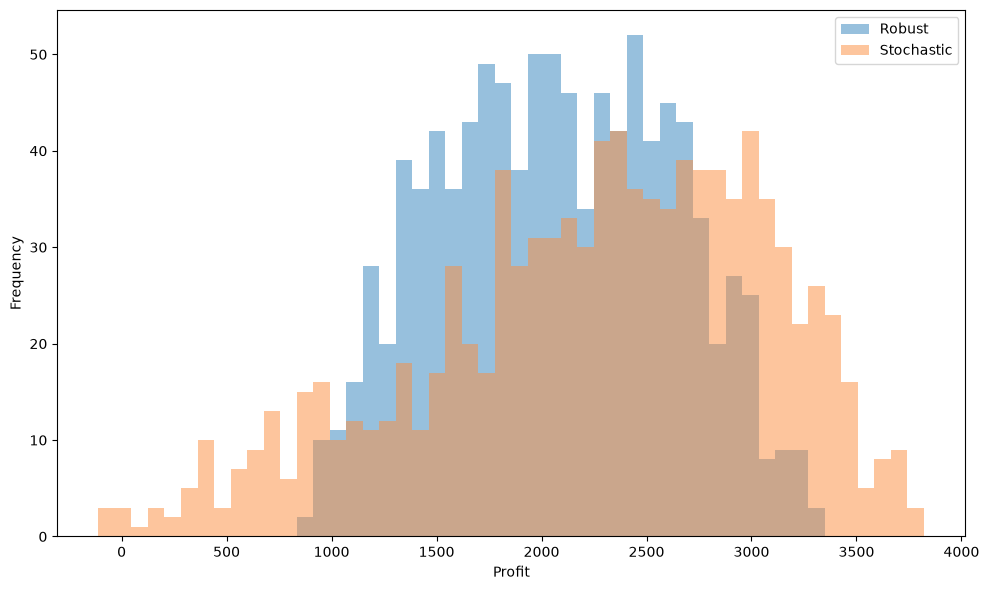

In [8]:
# Collecting the per-scenario optimal values of both the stochastic and robust problems
data = pd.DataFrame({"Robust": worst_case_ps, "Stochastic": avg_case_ps})

# Plotting the results in a histogram
colors = plt.cm.tab20c.colors
fig, ax = plt.subplots(figsize=(10, 6))
data.plot.hist(bins=50, alpha=0.5, ax=ax, color=[colors[0], colors[5]])
ax.set_xlabel("Profit")
plt.tight_layout()
plt.show()

What we observe is a very typical pattern: the robust solution's 'range' of values is narrower, both in the best- and worst-situation sense, it gives thus stabler profit relations. This comes, however, at the expense of having a worse performance in an 'average' scenario. You can expect to observe this kind of phenomenon very often whenever you need to solve a problem under uncertainty and are unsure whether the worst-case or average-case performance should be optimized for. The degree of tradeoff can help you then make the right decision.

## Constraint and column generation for the robust solution

Constraint and column generation (CCG) alternates a master problem with a worst-case subproblem. The master is the sampled max-min model above, starting from the nominal scenario, with the additional recourse-feasibility bound $x\geq250$. Each new scenario adds its production variables and constraints. Because the master considers only a subset of $Z$, its optimal profit is an **upper bound** on the continuous-set robust optimum.

For the master's order $\bar x$, the subproblem must compute

$$
W(\bar x)=\min_{z\in Z}Q(\bar x,z).
$$

Production must be allowed to adapt again after the new scenario is known. Searching only for a scenario that invalidates previously stored production plans is not equivalent to this subproblem: a new production plan might still work. Omitting the profit row from such a search also loses the profit guarantee.

We obtain an exact formulation of $W(\bar x)$ by dualizing the two-variable production LP. Let

$$
a_U(z)=140-50z_A-80z_B,\qquad a_V(z)=120-50z_A-40z_B.
$$

Associate nonnegative dual variables $\lambda_D,\lambda_U,\lambda_A,\lambda_B,\lambda_M$ with the preorder, upper demand, labor A, labor B and material constraints. Strong LP duality gives

$$
\begin{aligned}
W(\bar x)=\min_{z,\lambda}\quad
&-20(1+z_D)\lambda_D+40\lambda_U+80\lambda_A+100\lambda_B+\bar x\lambda_M\\
\text{s.t.}\quad
&-\lambda_D+\lambda_U+(1+z_A)\lambda_A+2(1+z_B)\lambda_B+10\lambda_M\geq a_U(z),\\
&(1+z_A)\lambda_A+(1+z_B)\lambda_B+9\lambda_M\geq a_V(z),\\
&z\in Z,\qquad\lambda\geq0.
\end{aligned}
$$

The recourse LP is feasible and bounded for every $z\in Z$ when $\bar x\geq250$. The auxiliary $y_3$ can be eliminated here because both unit contributions are positive. The products of uncertain parameters and dual variables make this subproblem nonconvex. We therefore solve it globally with SCIP; HiGHS continues to solve every master and fixed-scenario production model.

If the subproblem returns a global lower bound $L_W$ on $W(\bar x)$, then $-10\bar x+L_W$ is a **lower bound** on the robust optimum, associated with a feasible ordering decision. We retain the best such decision and stop only when the master's upper bound and the best lower bound differ by at most €0.01. A solver time limit or an iteration limit must not be reported as convergence.

In [9]:
from pyscipopt import Model as SCIPModel, quicksum

UNCERTAINTY_LIMITS = {"z_A": 0.15, "z_B": 0.25, "z_D": 0.25}
GAMMA = 2.0


def uncertainty_budget(z):
    return sum(abs(z[k]) / limit for k, limit in UNCERTAINTY_LIMITS.items())


def feasible_scenario(z, tolerance=1e-7):
    # Remove only solver roundoff, never a genuinely infeasible scenario.
    scaled = np.array([z[k] / limit for k, limit in UNCERTAINTY_LIMITS.items()])
    if np.max(np.abs(scaled)) > 1 + tolerance or np.abs(scaled).sum() > GAMMA + tolerance:
        raise RuntimeError("The worst-case solver returned a scenario outside Z.")
    scaled = np.clip(scaled, -1, 1)
    scaled *= min(1.0, GAMMA / max(GAMMA, np.abs(scaled).sum()))
    return {k: float(value * limit)
            for (k, limit), value in zip(UNCERTAINTY_LIMITS.items(), scaled)}

### Bounding the dual variables and encoding the budget

Finite, valid variable bounds help a global solver. For this instance we use

$$
(\lambda_D,\lambda_U,\lambda_A,\lambda_B,\lambda_M)
\leq(914,168,198,184,17).
$$

These bounds preserve at least one optimal dual solution for each scenario. To see this, substitute $y_1=20(1+z_D)+s$, $s\geq0$, in the production LP. For $\bar x\geq250$, all four remaining right-hand sides are nonnegative. The two objective coefficients are at most 167.5 and 137.5. In the resulting covering dual, any individual multiplier can be reduced to $168$, $198$, $184$ or $17$, respectively, without losing feasibility: these exceed the largest objective-to-column-coefficient ratios, using $1+z_A\geq0.85$ and $1+z_B\geq0.75$. The dual objective cannot increase because its coefficients are nonnegative. Returning to the original dual gives

$$
\lambda_D=\lambda_U+(1+z_A)\lambda_A+2(1+z_B)\lambda_B+10\lambda_M-a_U(z)
\leq168+1.15(198)+2.5(184)+10(17)-112.5=913.2.
$$

The bounds are specific to the stated data and must be re-derived if those data change.

The absolute-value budget uses $v_k\geq z_k$ **and** $v_k\geq-z_k$, together with $\sum_k v_k/\delta_k\leq2$. Keeping only the first inequality would allow negative deviations to escape the budget. We check the returned scenario's actual absolute-value budget separately.

In [10]:
def worst_case_profit(x_value, absolute_gap=0.001, time_limit=120):
    if x_value < 250 - 1e-7:
        raise ValueError("Robust recourse feasibility requires x >= 250.")
    sp = SCIPModel("Worst-case recourse profit")
    sp.hideOutput()
    sp.setParam("limits/time", time_limit)
    sp.setParam("limits/gap", 0.0)
    sp.setParam("limits/absgap", absolute_gap)
    sp.setParam("numerics/feastol", 1e-9)

    z = {k: sp.addVar(k, lb=-limit, ub=limit)
         for k, limit in UNCERTAINTY_LIMITS.items()}
    v = {k: sp.addVar("abs_" + k, lb=0, ub=limit)
         for k, limit in UNCERTAINTY_LIMITS.items()}
    for k in z:
        sp.addCons(v[k] >= z[k])
        sp.addCons(v[k] >= -z[k])
    sp.addCons(quicksum(v[k] / limit for k, limit in UNCERTAINTY_LIMITS.items()) <= GAMMA)

    bounds = {"D": 914, "U": 168, "A": 198, "B": 184, "M": 17}
    lam = {k: sp.addVar("lambda_" + k, lb=0, ub=bound)
           for k, bound in bounds.items()}
    a_u = 140 - 50 * z["z_A"] - 80 * z["z_B"]
    a_v = 120 - 50 * z["z_A"] - 40 * z["z_B"]
    sp.addCons(-lam["D"] + lam["U"] + (1 + z["z_A"]) * lam["A"]
               + 2 * (1 + z["z_B"]) * lam["B"] + 10 * lam["M"] >= a_u)
    sp.addCons((1 + z["z_A"]) * lam["A"]
               + (1 + z["z_B"]) * lam["B"] + 9 * lam["M"] >= a_v)
    value = sp.addVar("recourse_value", lb=-sp.infinity())
    sp.addCons(value >= -20 * (1 + z["z_D"]) * lam["D"] + 40 * lam["U"]
               + 80 * lam["A"] + 100 * lam["B"] + x_value * lam["M"])
    sp.setObjective(value, "minimize")
    sp.optimize()

    status = str(sp.getStatus())
    if status not in {"optimal", "gaplimit"} or sp.getNSols() == 0:
        raise RuntimeError(f"Worst-case solve did not finish to tolerance: {status}")
    lower, upper = sp.getDualbound(), sp.getObjVal()
    if not np.isfinite([lower, upper]).all() or upper - lower > absolute_gap + 1e-5:
        raise RuntimeError("The worst-case global bounds have not closed to tolerance.")
    raw_z = {k: sp.getVal(z[k]) for k in z}
    scenario = feasible_scenario(raw_z)

    # Independently re-optimize production at the returned scenario using HiGHS.
    recourse = max_profit_fixed_x(model_params, [scenario], x_value)
    solve_checked(recourse)
    checked_value = pyo.value(recourse.profit) + 10 * x_value
    if not lower - 1e-4 <= checked_value <= upper + 1e-4:
        raise RuntimeError("SCIP's bounds disagree with the fixed-scenario production LP.")
    return {"scenario": scenario, "lower_bound": lower, "upper_bound": upper,
            "recourse_value": checked_value, "status": status,
            "raw_budget": uncertainty_budget(raw_z),
            "budget": uncertainty_budget(scenario)}

### Running constraint and column generation

Each iteration solves the linear master, globally checks its ordering decision, and adds the worst-case scenario if the profit bounds have not met. All profit bounds below include the cost of the ordered material. The displayed gap is an absolute difference in euros, interpreted within the solvers' numerical feasibility tolerances.

In [11]:
ccg_scenarios = [{"z_A": 0.0, "z_B": 0.0, "z_D": 0.0}]
ccg_history = []
ccg_converged = False
stopping_precision = 0.01  # euros
max_iterations = 50
lower_bound = -np.inf
best_x = None

for iteration in range(max_iterations):
    master = max_min_profit(model_params, ccg_scenarios)
    master.x["x"].setlb(250)
    solve_checked(master)
    x_value = pyo.value(master.x["x"])
    upper_bound = pyo.value(master.worst_case_profit)
    worst = worst_case_profit(x_value)
    candidate_lower = worst["lower_bound"] - 10 * x_value
    if candidate_lower > lower_bound:
        lower_bound, best_x = candidate_lower, x_value
    gap = upper_bound - lower_bound
    if gap < -1e-4:
        raise RuntimeError("Inconsistent lower and upper profit bounds.")
    ccg_history.append({"Iteration": iteration, "Material order": x_value,
                        "Lower profit bound": lower_bound, "Upper profit bound": upper_bound,
                        "Gap": gap, "Scenario budget": worst["budget"]})
    print(f"Iteration {iteration}: x = {x_value:.4f}; "
          f"profit bounds [{lower_bound:.4f}, {upper_bound:.4f}]; gap = {max(0, gap):.6f}")
    if gap <= stopping_precision:
        ccg_converged = True
        break
    if any(max(abs(worst["scenario"][k] - old[k]) for k in UNCERTAINTY_LIMITS) < 1e-7
           for old in ccg_scenarios):
        raise RuntimeError("A repeated scenario was returned before the profit gap closed.")
    ccg_scenarios.append(worst["scenario"])

if not ccg_converged:
    raise RuntimeError("CCG reached the iteration limit without a profit certificate.")

print(f"\nRobust material order: {best_x:.4f}")
print(f"Guaranteed worst-case profit (global lower bound): {lower_bound:.4f} euros")
print(f"Optimal robust profit upper bound: {upper_bound:.4f} euros")
print(f"Master solves: {len(ccg_history)}; added scenarios: {len(ccg_scenarios) - 1}")

# Compare all decisions against the full uncertainty set and the original fixed sample.
comparison_rows = []
for label, order in [("Continuous-set robust", best_x), ("Sampled robust", xopt_rob), ("SAA", xopt_avg)]:
    worst_check = worst_case_profit(order)
    average_check = max_profit_fixed_x(model_params, Z, order, worst_case=False)
    solve_checked(average_check)
    comparison_rows.append({"Decision": label, "Material order": order,
                            "Worst-case profit lower bound": worst_check["lower_bound"] - 10 * order,
                            "Worst-case profit upper bound": worst_check["upper_bound"] - 10 * order,
                            "Mean sample profit": pyo.value(average_check.profit)})
continuous_comparison = pd.DataFrame(comparison_rows).set_index("Decision")
display(continuous_comparison.round(2))

Iteration 0: x = 740.0000; profit bounds [-1100.0000, 2600.0000]; gap = 3700.000009


Iteration 1: x = 520.0000; profit bounds [694.4444, 1100.0000]; gap = 405.555564


Iteration 2: x = 555.6098; profit bounds [743.9024, 743.9024]; gap = 0.000020

Robust material order: 555.6098
Guaranteed worst-case profit (global lower bound): 743.9024 euros
Optimal robust profit upper bound: 743.9024 euros
Master solves: 3; added scenarios: 2


,Material order,Worst-case profit lower bound,Worst-case profit upper bound,Mean sample profit
Decision,,,,
Continuous-set robust,555.61,743.90,743.90,2097.24
Sampled robust,547.81,733.07,733.07,2073.51
SAA,647.16,-171.58,-171.58,2255.78


The final table distinguishes a guarantee over the full uncertainty set from an average over the original 1,000 scenarios. CCG stops because its global profit bounds agree to the requested tolerance, not because a stored production plan passes a feasibility check. The iteration count and number of added scenarios are printed separately. They can vary with solver versions or alternative worst-case scenarios.

The comparison illustrates why the sampled worst-case profit can be optimistic: the random sample need not contain the most adverse boundary scenarios. The continuous-set robust decision protects its minimum profit, while the SAA decision prioritizes the mean under the assumed uniform distribution. The latter mean remains an in-sample estimate.

## Bibliographic Notes

* Zeng, B., & Zhao, L. (2013). Solving two-stage robust optimization problems using a column-and-constraint generation method. Operations Research Letters, 41(5), 457-461. 

The general CCG reference is available via [its DOI](https://doi.org/10.1016/j.orl.2013.05.003). For this example, the uncertain recourse coefficients require the global subproblem derived above. See also the [SCIP global optimization paper](https://arxiv.org/abs/2301.00587) and the [PySCIPOpt documentation](https://pyscipopt.readthedocs.io/en/stable/).